In [29]:
# 1. importing the required Python libraries
import numpy as np
from numpy import vstack, array
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pylab import plot, show


In [30]:
# Random data generation (2-D toy example)
rng = np.random.default_rng(5215)
data = vstack((rng.random((200, 2)) + array([0.5, 0.5]), rng.random((150, 2))))

# Normalizing the data (sklearn instead of scipy.whiten)
scaler = StandardScaler()
data = scaler.fit_transform(data)

# 2. computing K-Means with sklearn (K clusters)
K = 3
model = KMeans(n_clusters=K, n_init='auto', random_state=42)
clusters = model.fit_predict(data)
centroids = model.cluster_centers_

# Objective: inertia = sum of squared distances to closest centroid
inertia = float(model.inertia_)
mean_value = float(np.linalg.norm(data - centroids[clusters], axis=1).mean())

print("Centroids:\n", centroids, "\n")
print("Mean distance to assigned centroid :", round(mean_value, 4))
print("Inertia (sum of squared distances) :", round(inertia, 4))
print("\nCluster index :", clusters, "\n")

Centroids:
 [[-0.53197632  0.54869484]
 [-0.6670634  -1.11326233]
 [ 1.04084762  0.50256991]] 

Mean distance to assigned centroid : 0.8142
Inertia (sum of squared distances) : 276.1079

Cluster index : [0 0 2 0 2 0 2 2 2 2 1 0 0 0 2 0 2 2 0 2 2 0 2 0 0 2 2 2 2 2 2 0 0 2 2 0 2
 0 2 2 2 2 0 0 0 1 2 2 0 2 0 2 1 1 2 2 2 2 2 0 2 0 2 0 2 2 2 0 2 0 0 2 2 2
 2 2 2 0 2 0 2 2 2 0 2 2 0 2 2 2 0 0 2 0 2 2 0 2 2 2 2 1 2 0 0 0 0 2 2 0 1
 2 2 0 0 0 0 2 0 0 0 2 0 2 2 0 2 2 2 2 2 2 2 2 1 1 2 2 0 2 2 2 2 2 2 2 0 0
 2 2 2 2 2 2 2 0 2 2 0 1 2 1 0 2 0 2 1 1 2 2 1 2 2 2 0 2 2 2 2 2 0 0 0 2 2
 0 0 2 0 2 2 1 0 0 0 0 2 1 0 2 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1
 2 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1 2 0 0 1 0 0 1 1 1 0 1 1 1
 0 1 1 0 1 1 1 2 2 2 1 2 0 1 1 0 1 1 1 0 2 1 1 1 1 0 1 1 0 1 1 2 1 1 1 1 2
 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 1 1 2 1 1 1 1 1 1 0 1 1 1 1 0 1 2 1 0 0 0 1
 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1] 



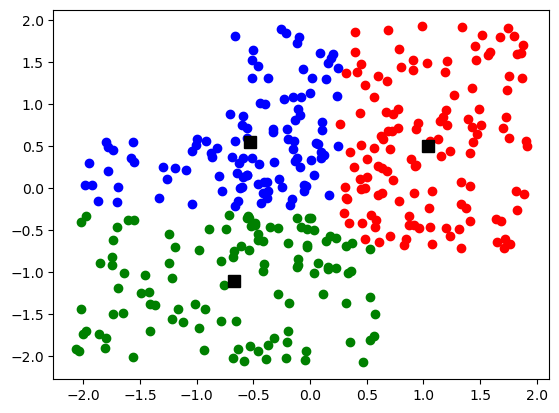

In [31]:
# 3. Plotting (works for any K)
color_cycle = np.array(list("bgrcmyk"))
for cluster_id in range(K):
    color = color_cycle[cluster_id % len(color_cycle)]
    fmt = "o" + color
    plot(data[clusters == cluster_id, 0], data[clusters == cluster_id, 1], fmt)

# centroids as black squares
plot(centroids[:, 0], centroids[:, 1], 'sk', markersize=8)
show()